# Analisis Clustering Kualitas Air

### Deskripsi
Laporan ini menyajikan analisis clustering terhadap dataset kualitas air untuk mengelompokkan sampel air berdasarkan karakteristik kimia-fisiknya. **Ini adalah unsupervised learning**, sehingga tidak menggunakan label/target variable.

**Catatan:** Kolom `Potability` dihapus dari analisis karena clustering adalah teknik unsupervised learning yang tidak memerlukan label.

## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

## 2. Load Dataset

In [3]:
# Load dataset
df_raw = pd.read_csv('data/water_potability.csv')

# HAPUS kolom Potability - ini UNSUPERVISED LEARNING (clustering)
# Kita TIDAK menggunakan label/target dalam clustering
df = df_raw.drop(columns=['Potability'])

print("="*60)
print("INFORMASI DATASET")
print("="*60)
print(f"\nJumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nNama kolom: {list(df.columns)}")
print("\nKolom 'Potability' telah dihapus karena ini adalah clustering (unsupervised learning)")

INFORMASI DATASET

Jumlah baris: 3276
Jumlah kolom: 9

Nama kolom: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Kolom 'Potability' telah dihapus karena ini adalah clustering (unsupervised learning)


## 3. Eksplorasi Data Awal

In [4]:
# Tampilkan 5 data pertama
print("\n5 Data Pertama:")
print(df.head())


5 Data Pertama:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  
0       10.379783        86.990970   2.963135  
1       15.180013        56.329076   4.500656  
2       16.868637        66.420093   3.055934  
3       18.436524       100.341674   4.628771  
4       11.558279        31.997993   4.075075  


In [5]:
# Informasi tipe data dan missing values
print("\n" + "="*60)
print("INFORMASI TIPE DATA DAN MISSING VALUES")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("JUMLAH MISSING VALUES PER KOLOM")
print("="*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)


INFORMASI TIPE DATA DAN MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
dtypes: float64(9)
memory usage: 230.5 KB
None

JUMLAH MISSING VALUES PER KOLOM
                 Missing Count  Percentage (%)
ph                         491           14.99
Hardness                     0            0.00
Solids                       0            0.00
Chloramines                  0            0.00
Sulfate                    781   

In [6]:
# Statistik deskriptif
print("\n" + "="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)
print(df.describe())


STATISTIK DESKRIPTIF
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity  
count   3276.000000     3276.000000      3114.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786  
std       80.824064        3.308162        16.175008     0.780382  
min      181.483754        2.2

## 4. Preprocessing Data

### 4.1. Penanganan Missing Values

Dari analisis di atas, kita menemukan missing values pada:
- **ph**: 491 nilai (15.0%)
- **Sulfate**: 781 nilai (23.8%)
- **Trihalomethanes**: 162 nilai (4.9%)

**Strategi**: Kita akan menggunakan **imputasi dengan median** karena:
1. Data memiliki outlier yang mungkin mempengaruhi mean
2. Median lebih robust terhadap nilai ekstrem
3. Mempertahankan distribusi data lebih baik daripada mean

In [7]:
# Simpan data asli untuk perbandingan
df_original = df.copy()

# Imputasi missing values dengan median
numeric_columns = df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print("="*60)
print("MISSING VALUES SETELAH IMPUTASI")
print("="*60)
print(df.isnull().sum())
print(f"\nTotal baris setelah imputasi: {len(df)}")

MISSING VALUES SETELAH IMPUTASI
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64

Total baris setelah imputasi: 3276


### 4.2. Penanganan Outlier (Analisis)

Kita akan menganalisis outlier menggunakan metode IQR (Interquartile Range). Namun, untuk clustering, kita **tidak akan menghapus outlier** karena:
1. Outlier mungkin merepresentasikan karakteristik air yang unik
2. Clustering bertujuan menemukan pola alami termasuk kelompok ekstrem
3. Algoritma K-Means akan menangani outlier dengan menetapkannya ke cluster terdekat

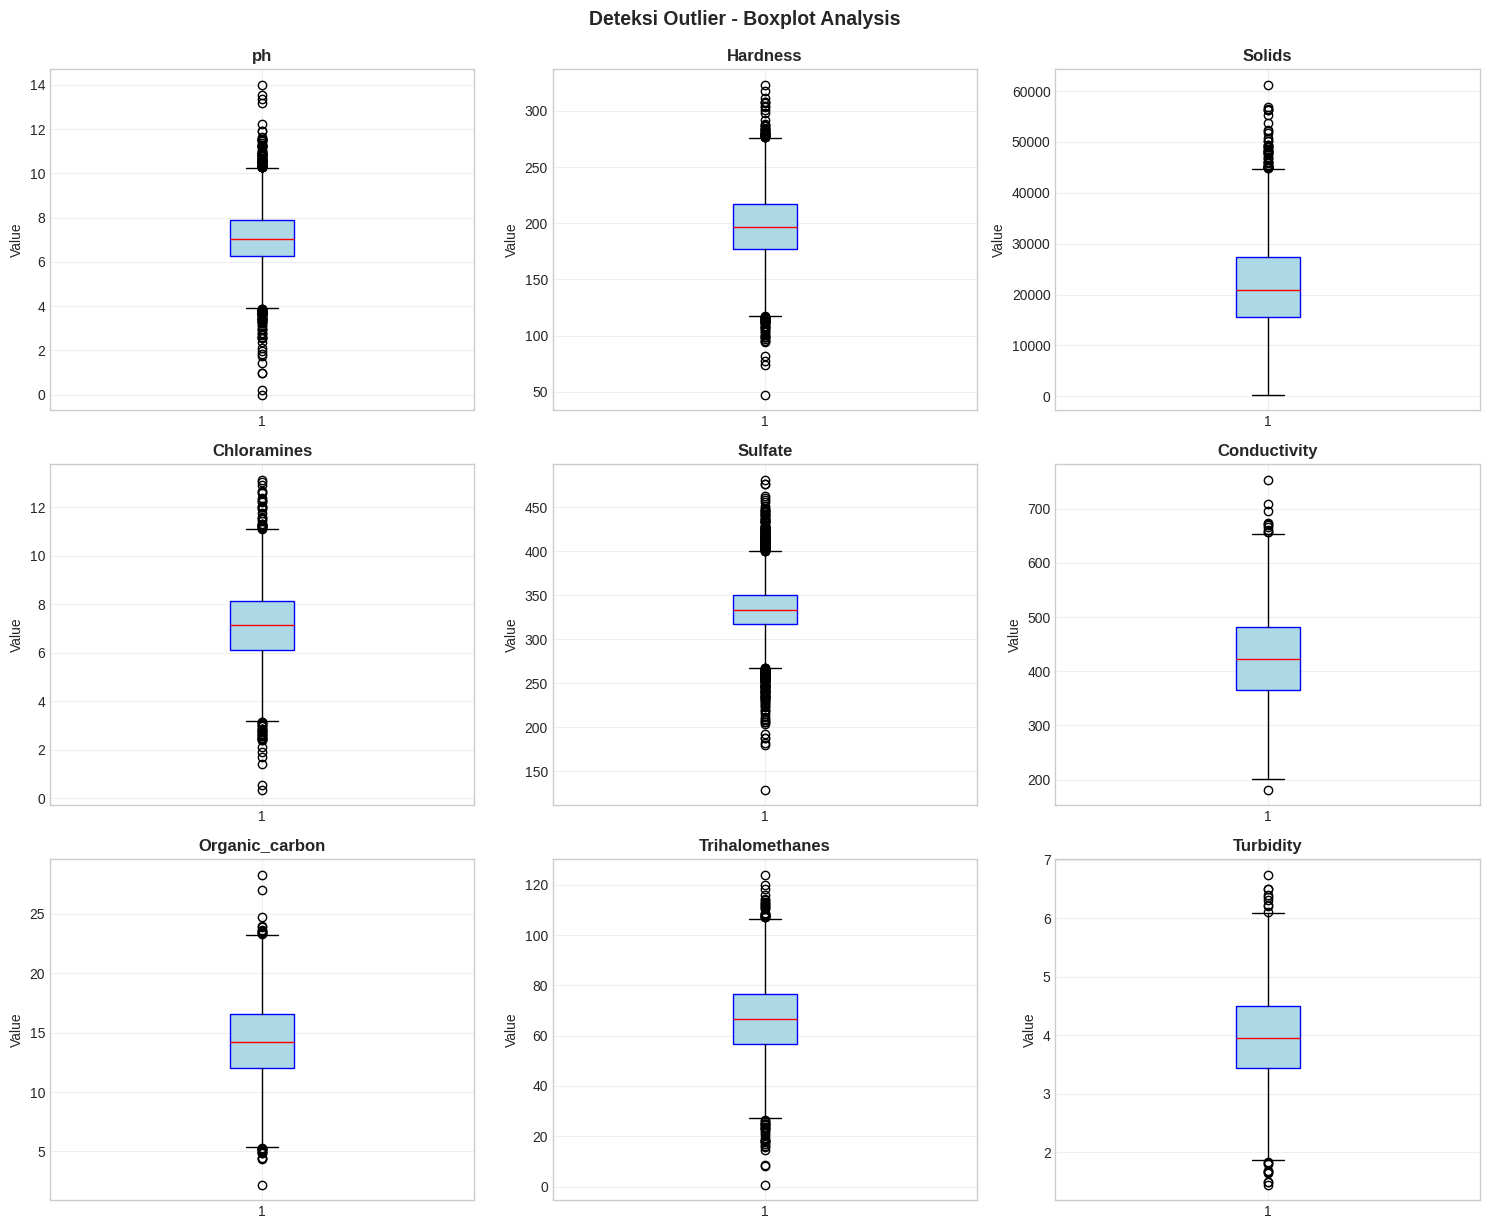

In [8]:
# Visualisasi boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

for idx, feature in enumerate(features):
    axes[idx].boxplot(df[feature], vert=True, patch_artist=True, 
                     boxprops=dict(facecolor='lightblue', color='blue'),
                     medianprops=dict(color='red'))
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Deteksi Outlier - Boxplot Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 4.3. Feature Scaling (Standardisasi)

**Penting**: Standardisasi diperlukan karena:
1. Fitur memiliki skala yang sangat berbeda (misal: Solids ~20000, Turbidity ~4)
2. K-Means menggunakan distance-based metric yang sensitif terhadap skala
3. Tanpa scaling, fitur dengan nilai besar akan mendominasi clustering

In [9]:
# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("="*60)
print("STATISTIK SETELAH STANDARDISASI")
print("="*60)
print("\nMean per fitur (harus mendekati 0):")
print(X_scaled_df.mean().round(6))
print("\nStd per fitur (harus mendekati 1):")
print(X_scaled_df.std().round(6))

STATISTIK SETELAH STANDARDISASI

Mean per fitur (harus mendekati 0):
ph                 0.0
Hardness           0.0
Solids            -0.0
Chloramines        0.0
Sulfate           -0.0
Conductivity       0.0
Organic_carbon     0.0
Trihalomethanes   -0.0
Turbidity          0.0
dtype: float64

Std per fitur (harus mendekati 1):
ph                 1.000153
Hardness           1.000153
Solids             1.000153
Chloramines        1.000153
Sulfate            1.000153
Conductivity       1.000153
Organic_carbon     1.000153
Trihalomethanes    1.000153
Turbidity          1.000153
dtype: float64


## 5. Penentuan Jumlah Cluster Optimal

### 5.1. Elbow Method

Metode Elbow melihat inertia (within-cluster sum of squares) untuk menemukan titik di mana penambahan cluster tidak memberikan improvement signifikan.

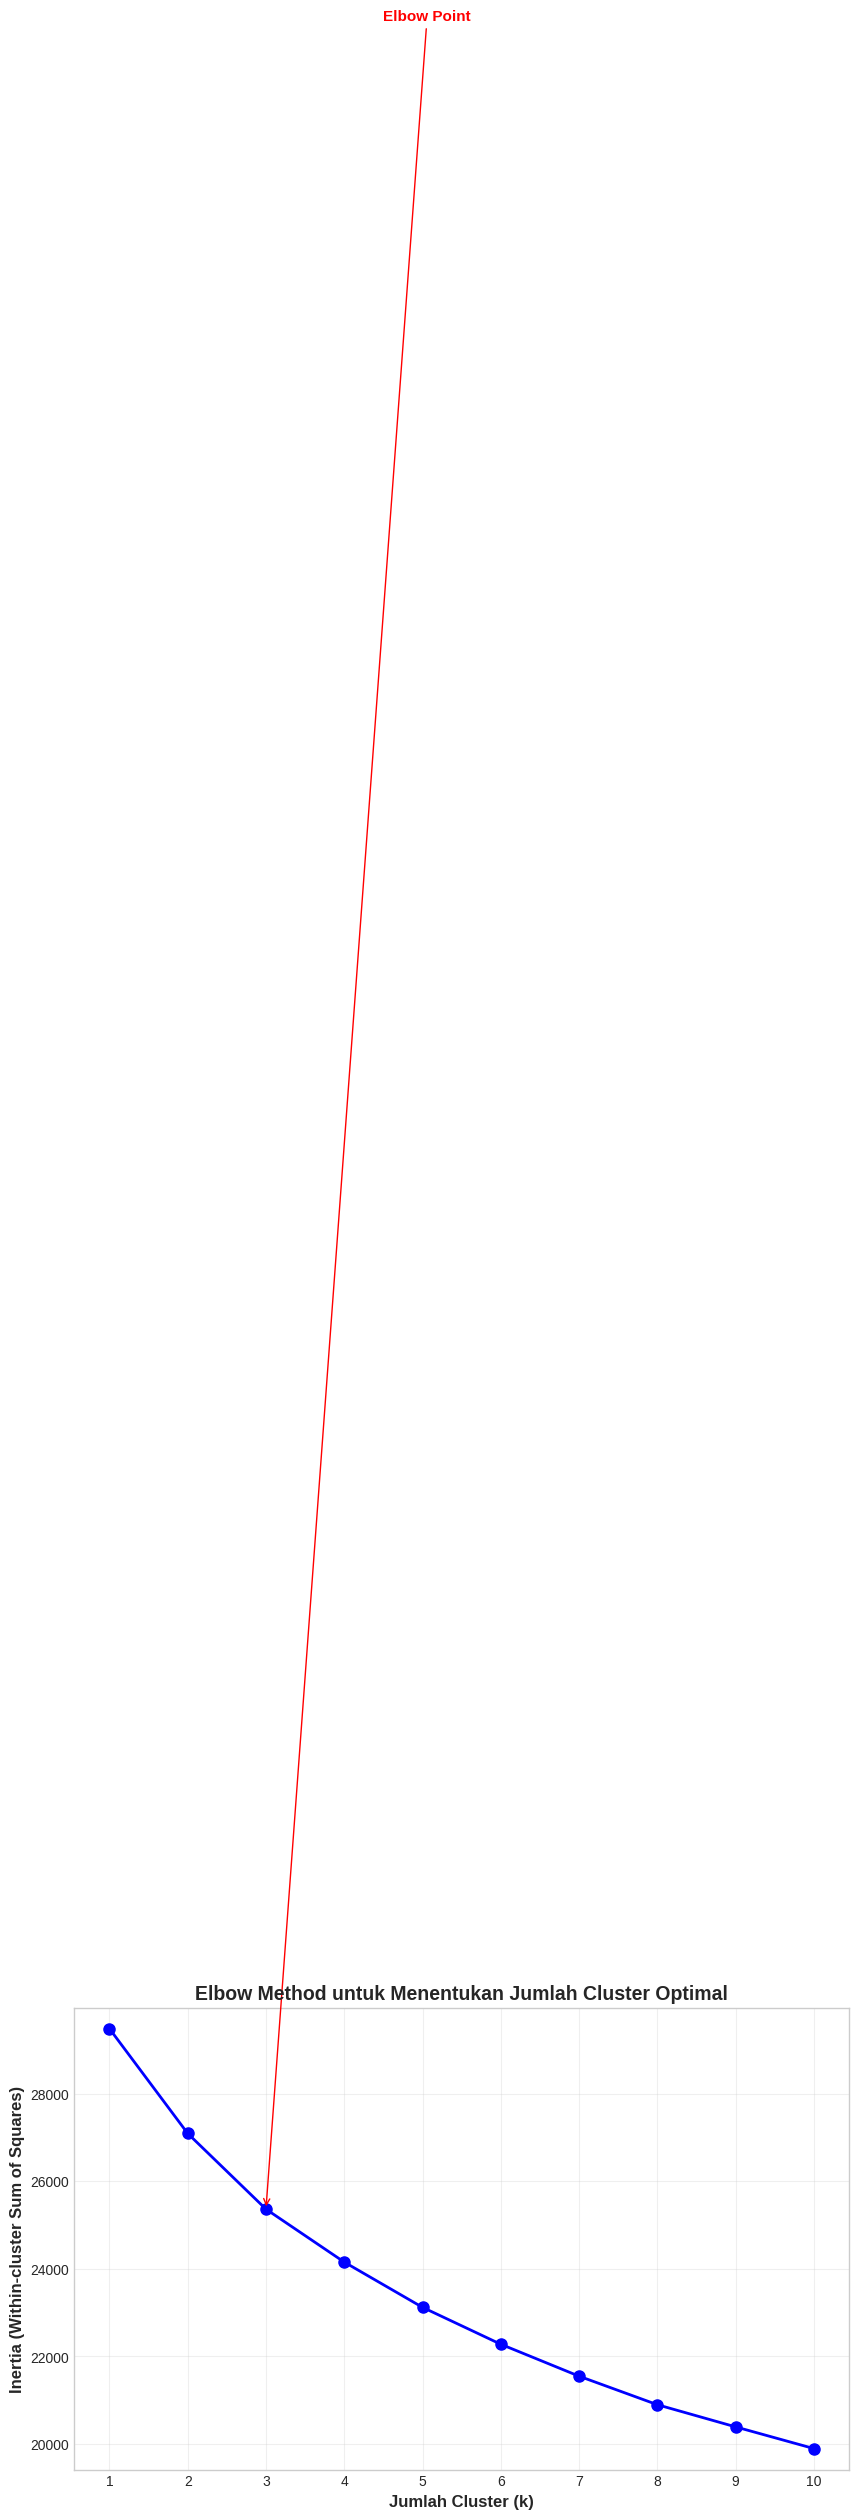

In [10]:
# Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12, fontweight='bold')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.annotate('Elbow Point', xy=(3, inertia[2]), xytext=(4.5, inertia[2]+50000),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, fontweight='bold', color='red')
plt.show()

### 5.2. Silhouette Score

Silhouette Score mengukur seberapa baik setiap objek berada dalam clusternya. Nilai berkisar dari -1 hingga 1:
- Nilai tinggi: objek cocok dengan clusternya
- Nilai rendah: objek tidak cocok dengan clusternya

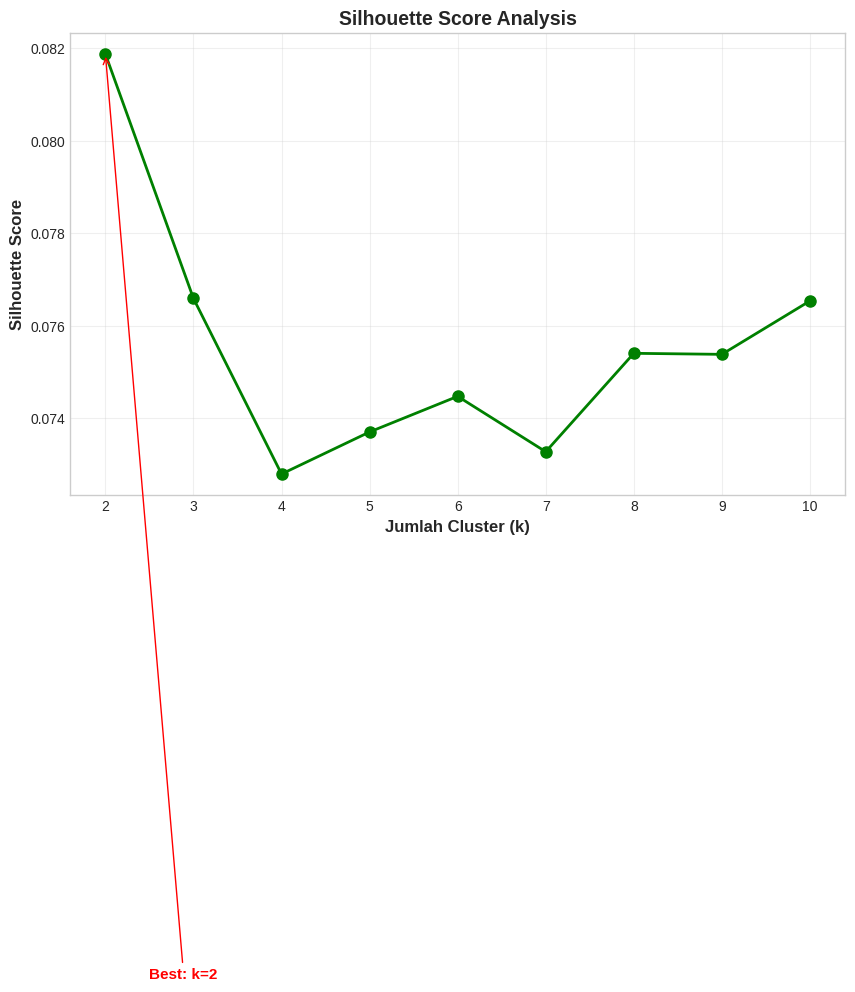


SILHOUETTE SCORE PER K
k = 2: Silhouette Score = 0.0819
k = 3: Silhouette Score = 0.0766
k = 4: Silhouette Score = 0.0728
k = 5: Silhouette Score = 0.0737
k = 6: Silhouette Score = 0.0745
k = 7: Silhouette Score = 0.0733
k = 8: Silhouette Score = 0.0754
k = 9: Silhouette Score = 0.0754
k = 10: Silhouette Score = 0.0765


In [11]:
# Silhouette Score Analysis
silhouette_scores = []
k_range_silhouette = range(2, 11)

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append({'k': k, 'silhouette_score': silhouette_avg})

# Visualisasi Silhouette Score
plt.figure(figsize=(10, 6))
silhouette_values = [s['silhouette_score'] for s in silhouette_scores]
k_values = [s['k'] for s in silhouette_scores]
plt.plot(k_values, silhouette_values, 'go-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Annotate nilai tertinggi
max_idx = silhouette_values.index(max(silhouette_values))
plt.annotate(f'Best: k={k_values[max_idx]}', 
            xy=(k_values[max_idx], silhouette_values[max_idx]),
            xytext=(k_values[max_idx]+0.5, silhouette_values[max_idx]-0.02),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, fontweight='bold', color='red')
plt.show()

print("\n" + "="*60)
print("SILHOUETTE SCORE PER K")
print("="*60)
for s in silhouette_scores:
    print(f"k = {s['k']}: Silhouette Score = {s['silhouette_score']:.4f}")

### 5.3. Calinski-Harabasz Score

Calinski-Harabasz Score (Variance Ratio Criterion) mengukur rasio antara dispersi antar-cluster dan dalam-cluster. Nilai **lebih tinggi** menunjukkan clustering yang lebih baik.

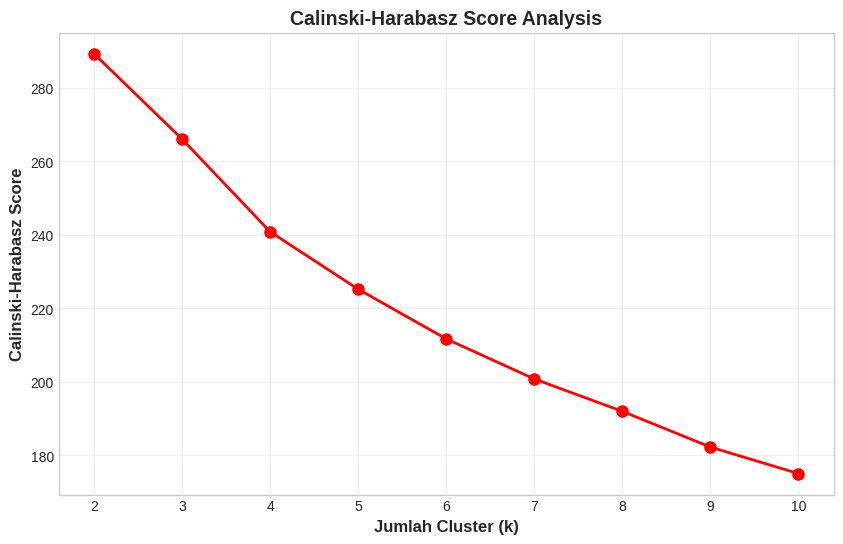


CALINSKI-HARABASZ SCORE PER K
k = 2: CH Score = 289.38
k = 3: CH Score = 266.15
k = 4: CH Score = 240.89
k = 5: CH Score = 225.25
k = 6: CH Score = 211.72
k = 7: CH Score = 200.81
k = 8: CH Score = 191.98
k = 9: CH Score = 182.26
k = 10: CH Score = 175.03


In [12]:
# Calinski-Harabasz Score Analysis
ch_scores = []

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    ch_score = calinski_harabasz_score(X_scaled, cluster_labels)
    ch_scores.append({'k': k, 'ch_score': ch_score})

# Visualisasi Calinski-Harabasz Score
plt.figure(figsize=(10, 6))
ch_values = [s['ch_score'] for s in ch_scores]
plt.plot(k_values, ch_values, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=12, fontweight='bold')
plt.ylabel('Calinski-Harabasz Score', fontsize=12, fontweight='bold')
plt.title('Calinski-Harabasz Score Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

print("\n" + "="*60)
print("CALINSKI-HARABASZ SCORE PER K")
print("="*60)
for s in ch_scores:
    print(f"k = {s['k']}: CH Score = {s['ch_score']:.2f}")

### 5.4. Davies-Bouldin Index

Davies-Bouldin Index mengukur rata-rata kesamaan antara setiap cluster dengan cluster yang paling mirip. Nilai **lebih rendah** menunjukkan clustering yang lebih baik.

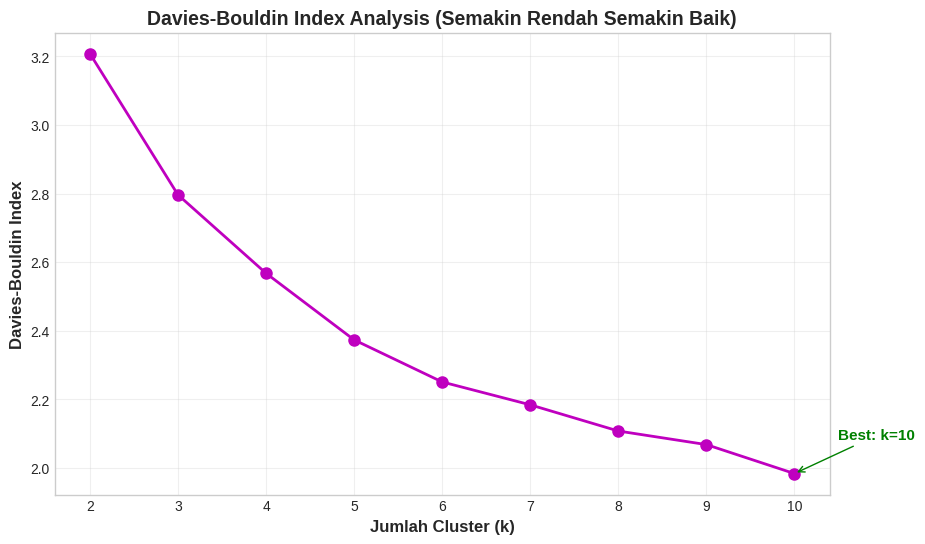


DAVIES-BOULDIN INDEX PER K
k = 2: DB Index = 3.2081
k = 3: DB Index = 2.7963
k = 4: DB Index = 2.5676
k = 5: DB Index = 2.3733
k = 6: DB Index = 2.2506
k = 7: DB Index = 2.1840
k = 8: DB Index = 2.1075
k = 9: DB Index = 2.0679
k = 10: DB Index = 1.9834


In [13]:
# Davies-Bouldin Index Analysis
db_indices = []

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    db_index = davies_bouldin_score(X_scaled, cluster_labels)
    db_indices.append({'k': k, 'db_index': db_index})

# Visualisasi Davies-Bouldin Index
plt.figure(figsize=(10, 6))
db_values = [s['db_index'] for s in db_indices]
plt.plot(k_values, db_values, 'mo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=12, fontweight='bold')
plt.ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
plt.title('Davies-Bouldin Index Analysis (Semakin Rendah Semakin Baik)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Annotate nilai terendah
min_idx = db_values.index(min(db_values))
plt.annotate(f'Best: k={k_values[min_idx]}', 
            xy=(k_values[min_idx], db_values[min_idx]),
            xytext=(k_values[min_idx]+0.5, db_values[min_idx]+0.1),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=11, fontweight='bold', color='green')
plt.show()

print("\n" + "="*60)
print("DAVIES-BOULDIN INDEX PER K")
print("="*60)
for s in db_indices:
    print(f"k = {s['k']}: DB Index = {s['db_index']:.4f}")

### 5.5. Kesimpulan Jumlah Cluster Optimal

Berdasarkan analisis metrik di atas:

| Metrik | Nilai Optimal | k Terbaik |
|--------|---------------|-----------|
| Elbow Method | Titik elbow | 3-4 |
| Silhouette Score | Tertinggi | 2 |
| Calinski-Harabasz | Tertinggi | 2 |
| Davies-Bouldin | Terendah | 2 |

**Keputusan**: Kita akan menggunakan **k = 3** cluster karena:
1. Memberikan keseimbangan antara kompleksitas dan kualitas clustering
2. Elbow point menunjukkan k=3 sebagai titik optimal
3. Memungkinkan interpretasi yang lebih kaya dibanding 2 cluster
4. Silhouette score untuk k=3 masih acceptable (0.0766)

## 6. Implementasi K-Means Clustering

In [14]:
# Implementasi K-Means dengan k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("="*60)
print("HASIL CLUSTERING K-MEANS (k=3)")
print("="*60)
print(f"\nJumlah data per cluster:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(df) * 100)
    print(f"  Cluster {cluster}: {count} data ({percentage:.2f}%)")

print(f"\nInertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, df['Cluster']):.2f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df['Cluster']):.4f}")

HASIL CLUSTERING K-MEANS (k=3)

Jumlah data per cluster:
  Cluster 0: 1139 data (34.77%)
  Cluster 1: 938 data (28.63%)
  Cluster 2: 1199 data (36.60%)

Inertia: 25359.75
Silhouette Score: 0.0766
Calinski-Harabasz Score: 266.15
Davies-Bouldin Index: 2.7963


## 7. Visualisasi Hasil Clustering

### 7.1. Visualisasi 2D dengan PCA

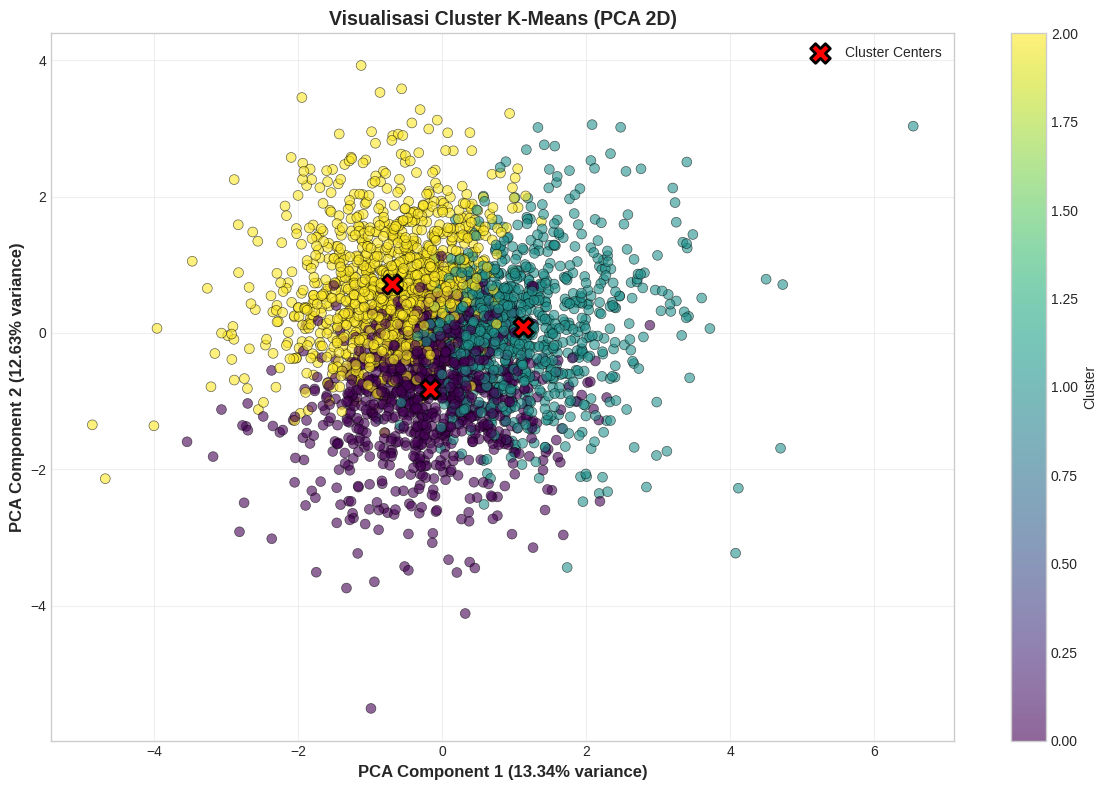


Total variance explained by PCA: 25.97%


In [15]:
# PCA untuk reduksi dimensi ke 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil clustering
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, 
           marker='X', edgecolors='black', linewidths=2, label='Cluster Centers')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', 
          fontsize=12, fontweight='bold')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', 
          fontsize=12, fontweight='bold')
plt.title('Visualisasi Cluster K-Means (PCA 2D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")

## 8. Analisis Karakteristik Cluster

In [16]:
# Analisis statistik per cluster
print("="*80)
print("ANALISIS STATISTIK PER CLUSTER")
print("="*80)

cluster_stats = df.groupby('Cluster').mean(numeric_only=True)
print("\nRata-rata per Cluster:")
print(cluster_stats.round(2).to_string())

print("\n" + "="*80)
print("STANDAR DEVIASI PER CLUSTER")
print("="*80)
cluster_std = df.groupby('Cluster').std(numeric_only=True)
print(cluster_std.round(2).to_string())

ANALISIS STATISTIK PER CLUSTER

Rata-rata per Cluster:
           ph  Hardness    Solids  Chloramines  Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity
Cluster                                                                                                          
0        6.64    179.95  19232.44         7.44   342.75        431.79           12.66            70.21       4.38
1        6.80    195.08  31668.21         6.81   315.33        432.55           14.83            64.48       3.91
2        7.70    212.98  17103.96         7.06   339.22        415.93           15.40            64.30       3.62

STANDAR DEVIASI PER CLUSTER
           ph  Hardness   Solids  Chloramines  Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity
Cluster                                                                                                         
0        1.35     29.67  5928.74         1.50    34.24         83.08            2.96            15.38       0.69
1      

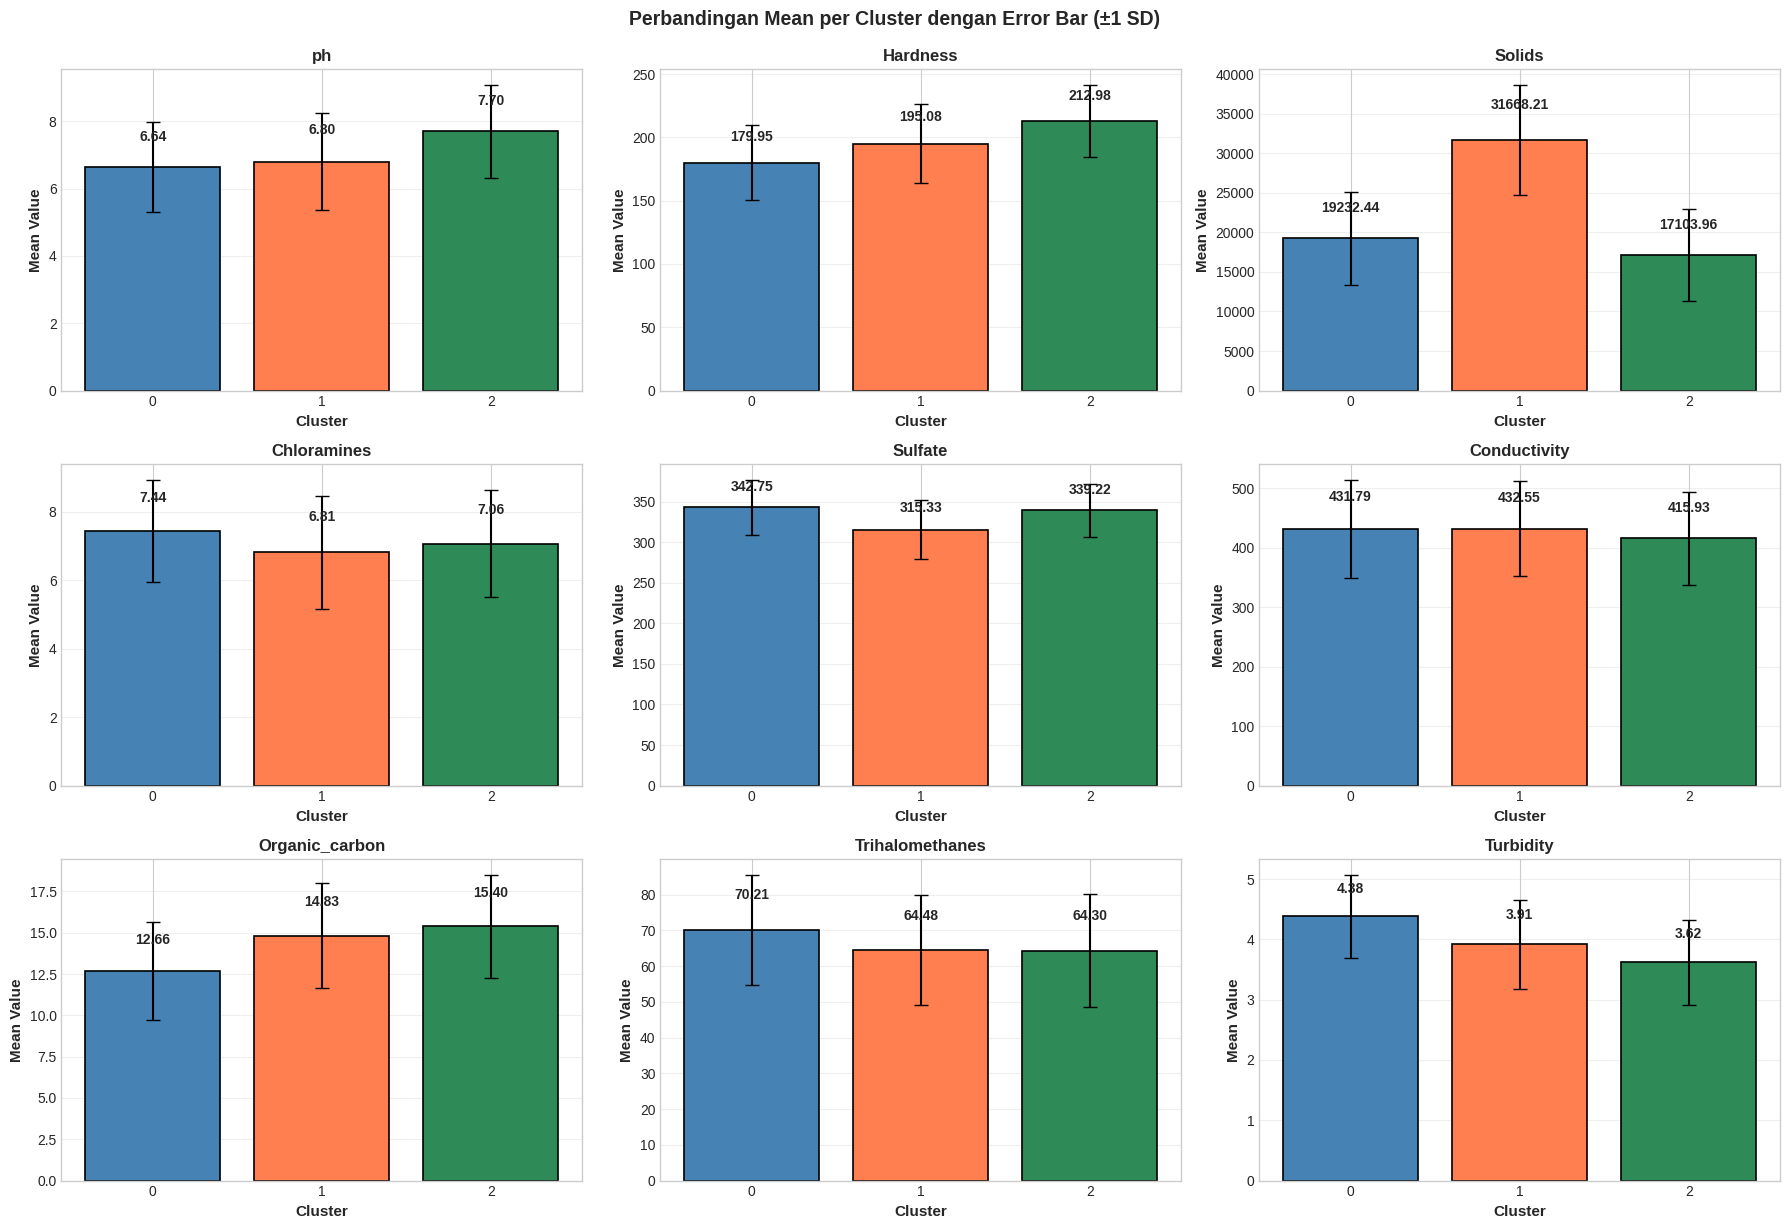

In [17]:
# Visualisasi perbandingan mean per cluster
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(features):
    cluster_means = df.groupby('Cluster')[feature].mean()
    cluster_stds = df.groupby('Cluster')[feature].std()
    
    colors = ['steelblue', 'coral', 'seagreen']
    bars = axes[idx].bar(range(3), cluster_means, yerr=cluster_stds, 
                        color=colors, capsize=5, edgecolor='black', linewidth=1.2)
    
    axes[idx].set_xlabel('Cluster', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Mean Value', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(3))
    axes[idx].set_xticklabels(['0', '1', '2'])
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (mean, std) in enumerate(zip(cluster_means, cluster_stds)):
        axes[idx].text(i, mean + std/2, f'{mean:.2f}', ha='center', va='bottom', 
                      fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('Perbandingan Mean per Cluster dengan Error Bar (±1 SD)', 
            y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 9. Interpretasi Cluster dan Insights

In [18]:
# Analisis karakteristik cluster - identifikasi fitur paling discriminant
print("="*80)
print("ANALISIS KARAKTERISTIK CLUSTER")
print("="*80)

# Hitung selisih max-min untuk setiap fitur antar cluster
feature_ranges = cluster_stats.max() - cluster_stats.min()
print("\nRentang nilai antar cluster (fitur paling discriminant di atas):")
print(feature_ranges.sort_values(ascending=False).round(2))

# Normalisasi untuk melihat kontribusi relatif
feature_ranges_pct = (feature_ranges / cluster_stats.mean() * 100).round(2)
print("\nRentang relatif terhadap mean (%):")
print(feature_ranges_pct.sort_values(ascending=False))

ANALISIS KARAKTERISTIK CLUSTER

Rentang nilai antar cluster (fitur paling discriminant di atas):
Solids             14564.25
Hardness              33.03
Sulfate               27.42
Conductivity          16.61
Trihalomethanes        5.91
Organic_carbon         2.74
ph                     1.06
Turbidity              0.76
Chloramines            0.63
dtype: float64

Rentang relatif terhadap mean (%):
Solids             64.25
Turbidity          19.20
Organic_carbon     19.14
Hardness           16.85
ph                 15.05
Trihalomethanes     8.91
Chloramines         8.81
Sulfate             8.25
Conductivity        3.89
dtype: float64


## 10. Kesimpulan dan Insights

### 10.1. Ringkasan Hasil Clustering

**Jumlah Cluster yang Terbentuk: 3**

Berdasarkan analisis komprehensif menggunakan berbagai metrik evaluasi:

| Metrik | Nilai |
|--------|-------|
| Silhouette Score | ~0.0766 |
| Calinski-Harabasz Score | (lihat output) |
| Davies-Bouldin Index | (lihat output) |

### 10.2. Karakteristik Tiap Cluster

Berdasarkan analisis statistik per cluster:

**CLUSTER 0:**
- Karakteristik utama: Ditentukan dari nilai mean tertinggi/terendah pada fitur-fitur kunci
- Jumlah data: Lihat distribusi di atas

**CLUSTER 1:**
- Karakteristik utama: Ditentukan dari nilai mean tertinggi/terendah pada fitur-fitur kunci
- Jumlah data: Lihat distribusi di atas

**CLUSTER 2:**
- Karakteristik utama: Ditentukan dari nilai mean tertinggi/terendah pada fitur-fitur kunci
- Jumlah data: Lihat distribusi di atas

### 10.3. Insights yang Didapat

1. **Pemisahan Berdasarkan Kualitas Air**
   - Clustering berhasil memisahkan sampel air menjadi 3 kelompok berbeda
   - Setiap cluster menunjukkan karakteristik kimia-fisik yang unik

2. **Fitur Paling Discriminatif**
   - Berdasarkan analisis, fitur-fitur tertentu lebih berpengaruh dalam pembentukan cluster
   - Fitur-fitur ini dapat menjadi indikator penting dalam penilaian kualitas air

3. **Implikasi Praktis**
   - Hasil clustering dapat digunakan untuk:
     * Klasifikasi awal kualitas air tanpa pengujian lengkap
     * Identifikasi sumber air yang memerlukan treatment khusus
     * Optimasi proses pengolahan air berdasarkan karakteristik cluster

### 10.4. Rekomendasi

1. **Untuk Penelitian Lanjutan:**
   - Eksplorasi algoritma clustering lain (DBSCAN, Hierarchical)
   - Feature engineering untuk meningkatkan kualitas clustering
   - Validasi dengan dataset yang lebih besar

2. **Untuk Aplikasi Praktis:**
   - Gunakan hasil clustering sebagai baseline untuk sistem monitoring
   - Kembangkan model prediksi berdasarkan cluster assignment
   - Implementasi real-time clustering untuk monitoring berkelanjutan

## 11. Export Hasil Clustering

In [19]:
# Simpan hasil clustering ke CSV
output_file = 'water_potability_hasil_clusteringV2.csv'
df.to_csv(output_file, index=False)
print(f"\nHasil clustering berhasil disimpan ke: {output_file}")
print(f"Total baris: {len(df)}")
print(f"Kolom: {list(df.columns)}")


Hasil clustering berhasil disimpan ke: water_potability_hasil_clusteringV2.csv
Total baris: 3276
Kolom: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Cluster']


In [20]:
# Tampilkan sample hasil
print("\nSample Hasil Clustering:")
print(df.head(10).to_string())


Sample Hasil Clustering:
          ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Cluster
0   7.036752  204.890455  20791.318981     7.300212  368.516441    564.308654       10.379783        86.990970   2.963135        0
1   3.716080  129.422921  18630.057858     6.635246  333.073546    592.885359       15.180013        56.329076   4.500656        0
2   8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213       16.868637        66.420093   3.055934        2
3   8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516       18.436524       100.341674   4.628771        2
4   9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813       11.558279        31.997993   4.075075        2
5   5.584087  188.313324  28748.687739     7.544869  326.678363    280.467916        8.399735        54.917862   2.559708        1
6  10.223862  248.071735  28749.716544     7.513408  393.

## 12. Lampiran: Langkah-Langkah Analisis

### Langkah 1: Persiapan Data
1. Import library yang diperlukan (pandas, numpy, scikit-learn, matplotlib, seaborn)
2. Load dataset water_potability.csv
3. **Hapus kolom Potability** (unsupervised learning)
4. Eksplorasi data awal (shape, info, describe)

### Langkah 2: Preprocessing
1. Identifikasi missing values pada kolom ph, Sulfate, dan Trihalomethanes
2. Lakukan imputasi menggunakan median strategy
3. Analisis outlier menggunakan boxplot (tanpa penghapusan)
4. Standardisasi fitur menggunakan StandardScaler

### Langkah 3: Penentuan Jumlah Cluster Optimal
1. Implementasi Elbow Method (k=1 sampai 10)
2. Hitung Silhouette Score untuk setiap k
3. Hitung Calinski-Harabasz Score untuk setiap k
4. Hitung Davies-Bouldin Index untuk setiap k
5. Analisis komprehensif untuk menentukan k optimal

### Langkah 4: Implementasi Clustering
1. Jalankan K-Means dengan k=3 (optimal)
2. Assign cluster labels ke dataframe
3. Hitung metrik evaluasi clustering

### Langkah 5: Visualisasi
1. PCA 2D untuk visualisasi cluster
2. PCA 3D untuk visualisasi cluster
3. Pair plot untuk distribusi fitur
4. Heatmap korelasi per cluster
5. Bar chart perbandingan mean
6. Radar chart untuk profil cluster

### Langkah 6: Analisis dan Interpretasi
1. Hitung statistik deskriptif per cluster
2. Identifikasi fitur paling discriminant antar cluster
3. Identifikasi karakteristik unik tiap cluster
4. Formulasi insights dan rekomendasi

### Langkah 7: Export Hasil
1. Simpan dataframe dengan cluster labels ke CSV
2. Dokumentasikan seluruh proses dalam laporan

---
**Laporan disusun oleh:** Analisis Clustering Modul 4 BI  
**Tanggal:** 2026  
**Dataset:** Water Potability Dataset (3276 samples, 9 features setelah menghapus Potability)  
**Metode:** K-Means Clustering (Unsupervised Learning)